In [116]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


dk062 v5 fail 


In [117]:
from pathlib import Path
import jsonpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Base data directory
PROJECT_ROOT = Path.cwd()

dataPath = PROJECT_ROOT / "data/"
# Parameters
mouse = "dk058"
new = "data_rxn"
date = "2026-05-27"

# Construct the folder path
sessionPath = dataPath / new / mouse / "touchDict_v5_20260527_paq0009.json"

with sessionPath.open('r') as f:
    touchDict = jsonpickle.decode(f.read())


/var/folders/6c/kv9rjx1d2pl_7sgjzszvh8sc0000gn/T/ipykernel_31122/4154821725.py:21: DeprecationWarning: keys will default to True in jsonpickle 5.0.0
  touchDict = jsonpickle.decode(f.read())


In [118]:
# add another mouse 
mouse_v2 = "sg024/sg024_2026-02-24_v2_touchDict_aligned.json"
mouse_v3 = "sg024/sg024_2026-02-24_v3_touchDict_aligned.json"
sessionPath = dataPath / mouse_v2
sessionPath_v3 = dataPath / mouse_v3
with sessionPath.open("r") as f:
    touchDict_v2 = jsonpickle.decode(f.read())
with sessionPath_v3.open("r") as f:
    touchDict_v3 = jsonpickle.decode(f.read())

/var/folders/6c/kv9rjx1d2pl_7sgjzszvh8sc0000gn/T/ipykernel_31122/1970537549.py:7: DeprecationWarning: keys will default to True in jsonpickle 5.0.0
  touchDict_v2 = jsonpickle.decode(f.read())
/var/folders/6c/kv9rjx1d2pl_7sgjzszvh8sc0000gn/T/ipykernel_31122/1970537549.py:9: DeprecationWarning: keys will default to True in jsonpickle 5.0.0
  touchDict_v3 = jsonpickle.decode(f.read())


In [119]:
from organise_touch_trials import merge_touchDicts, organise_dataset
merged = merge_touchDicts([touchDict_v2, touchDict_v3], labels=['1port', '2port'])
organised = organise_dataset(merged)
organised.summary()

[organise_touch_trials] Detected layout: zF time axis=2 (n_time=120, n_features=578); npix time axis=2 (n_time=400, n_features=72). Canonicalizing both to (trial, time, feature).
iCueL_1port_cor      n_trials= 120  zF=(120, 120, 578)  npix_ds=(120, 120, 72)
iCueL_1port_inc      n_trials=   0  zF=(0, 120, 578)  npix_ds=(0, 120, 72)
iCueL_1port_nochoice n_trials=   0  zF=(0, 120, 578)  npix_ds=(0, 120, 72)
iCueR_1port_cor      n_trials= 120  zF=(120, 120, 578)  npix_ds=(120, 120, 72)
iCueR_1port_inc      n_trials=   0  zF=(0, 120, 578)  npix_ds=(0, 120, 72)
iCueR_1port_nochoice n_trials=   0  zF=(0, 120, 578)  npix_ds=(0, 120, 72)
iCueL_2port_cor      n_trials=  28  zF=(28, 120, 578)  npix_ds=(28, 120, 72)
iCueL_2port_inc      n_trials=   9  zF=(9, 120, 578)  npix_ds=(9, 120, 72)
iCueL_2port_nochoice n_trials=   0  zF=(0, 120, 578)  npix_ds=(0, 120, 72)
iCueR_2port_cor      n_trials=  24  zF=(24, 120, 578)  npix_ds=(24, 120, 72)
iCueR_2port_inc      n_trials=  31  zF=(31, 120, 578)  npix

In [120]:
# import sys

# from organise_touch_trials import organise_dataset, plot_condition_comparison

# organised = organise_dataset(touchDict)
# organised.summary()

# plot_condition_comparison(organised, ['iCueR_1port_cor', 'iCueL_1port_cor'], feature_idx=0)


In [209]:
from CCA_analysis import run_shared_cca, plot_cca_cv_correlations

# define conditions - pool condition labels and give name to each condition
cond_1 = organised.pool(
    [
        "iCueL_1port_cor",
        # "iCueL_2port_cor",
    ],
    name="Left Cor",
)
cond_2 = organised.pool(
    [
        "iCueR_1port_cor",
        # "iCueR_2port_cor",
    ],
    name="Right Cor",
)
cond_3 = organised.pool(
    [
        "iCueL_1port_inc",
        "iCueL_2port_inc",
    ],
    name="Left Inc",
)
cond_4 = organised.pool(
    [
        "iCueR_1port_inc",
        "iCueR_2port_inc",
    ],
    name="Right Inc",
)
conditions = [cond_1, cond_2]
cca_res_shared = run_shared_cca(
    conditions,
    fit='shared',
    zone=None, 
    neuron_zone=None, # can restrict to microzone
    x_attr="npix_ds",
    y_attr="zF",
    scale=True, # z scoring - only applied to npix_ds, not zF because it is already z scored
    n_pca_components=None, # pca (if none, no pca)
    n_cca_components=5,
    temporal_window=(-0.7, 0.7), # can cut to time window
    time=organised.time_zF, # if want to cut to time window, need to provide time vector
    test_size=0.2,
    stratify=True, # stratify by trial type
    cv=True,
    max_folds=5,
    random_state=69,
    verbose=True, 
)


[organise_touch_trials] pool(): skipping empty/missing conditions ['iCueL_1port_inc']
[organise_touch_trials] pool(): skipping empty/missing conditions ['iCueR_1port_inc']
X trials: (240, 120, 72)  Y trials: (240, 120, 578)  (all neurons)
Left Cor: 120 trials, Right Cor: 120 trials
Restricting to temporal window (-0.7, 0.7): 42 timepoints remain.
Cross-validated diagnostic (training trials only):
Fold 1: held-out trials [  1   6  10  11  16  24  29  39  44  51  56  61  66  72  75  80  85  90
  94  97  99 104 109 114 122 127 131 132 137 149 154 159 164 168 172 177
 182 187 191]; test correlations {'Left Cor': array([ 0.521,  0.249,  0.203, -0.001,  0.068]), 'Right Cor': array([0.465, 0.4  , 0.259, 0.233, 0.042])}
Fold 2: held-out trials [  0   5  15  20  21  22  28  33  38  43  50  55  60  65  74  79  83  84
  89  95  98 103 107 108 113 121 126 136 141 144 148 153 158 163 171 176
 181 186 190]; test correlations {'Left Cor': array([0.608, 0.371, 0.292, 0.036, 0.027]), 'Right Cor': array

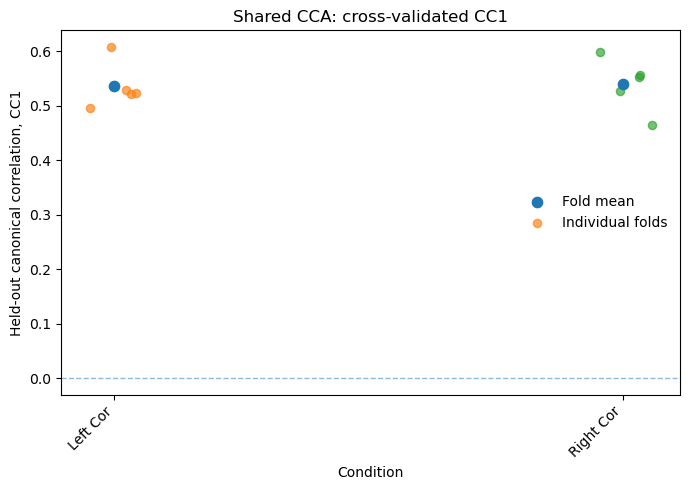

In [210]:
fig, ax, shared_plot_data = plot_cca_cv_correlations(
    cca_res_shared,
    conditions=[cond_1, cond_2],
    fit="shared",
    component=0,          # CC1
    show_individual=True,
    show_errorbars=False,
)

plt.show()

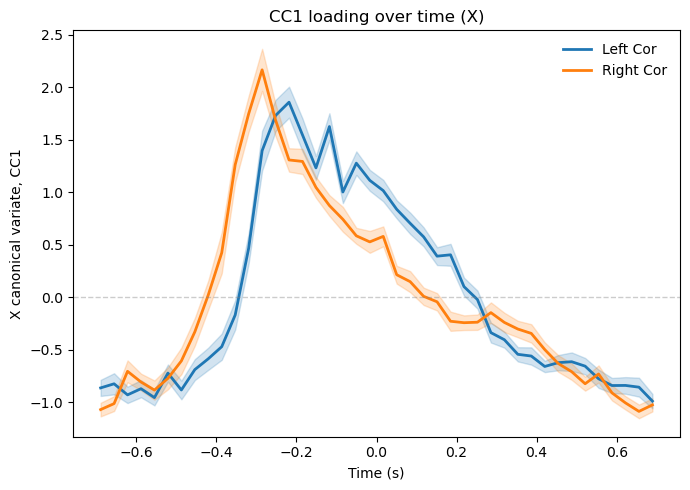

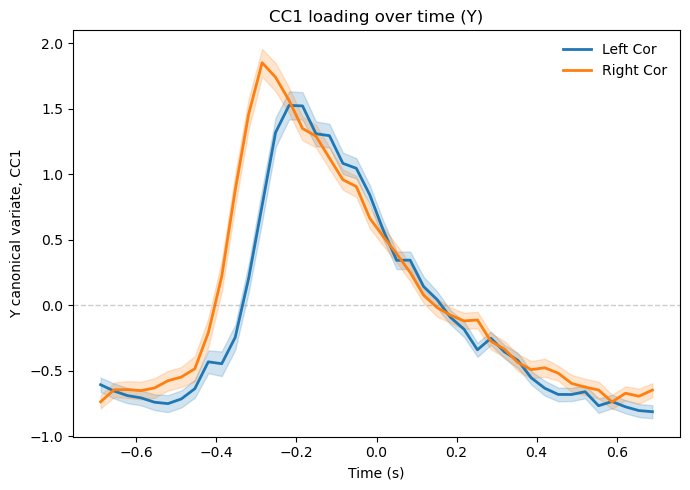

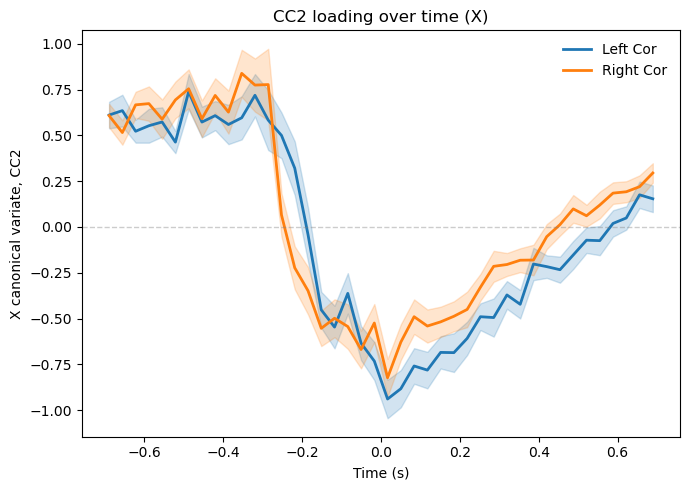

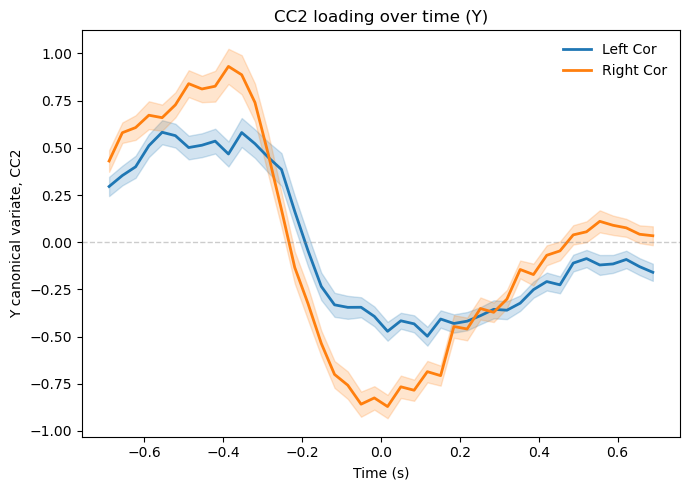

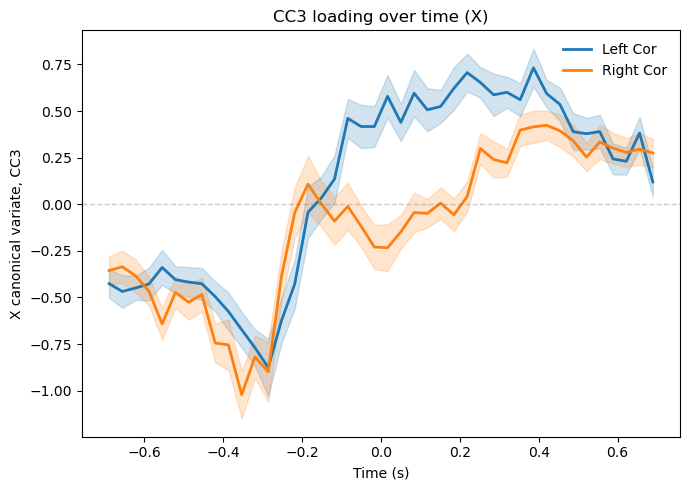

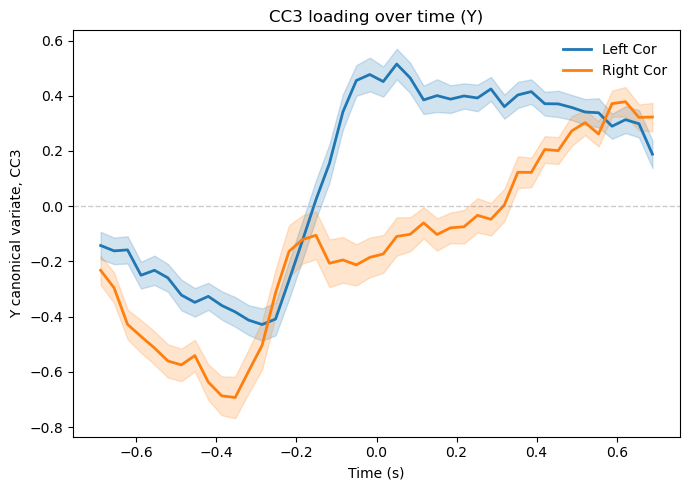

In [211]:
# get trajectories for shared CCA per condition 
time_axis = organised.time_zF
start = -0.7
end = 0.7
mask = (time_axis >= start) & (time_axis <= end) # use mask by doing time_axis[mask] to get the time vector for plottingIF YOU CUT THE TIME WINDOW 
from CCA_analysis import plot_cca_component_timecourse,plot_cca_state_space
fig, ax, X_CC1 = plot_cca_component_timecourse(
    cca_res_shared, which="X", component=0, time=time_axis[mask]
)
fig, ax, Y_CC1 = plot_cca_component_timecourse(
    cca_res_shared, which="Y", component=0, time=time_axis[mask]
)
fig, ax, X_CC2 = plot_cca_component_timecourse(
    cca_res_shared, which="X", component=1, time=time_axis[mask]
)
fig, ax, Y_CC2 = plot_cca_component_timecourse(
    cca_res_shared, which="Y", component=1, time=time_axis[mask]
)
fig, ax, X_CC3 = plot_cca_component_timecourse(
    cca_res_shared, which="X", component=2, time=time_axis[mask]
)
fig, ax, Y_CC3 = plot_cca_component_timecourse(
    cca_res_shared, which="Y", component=2, time=time_axis[mask]
)



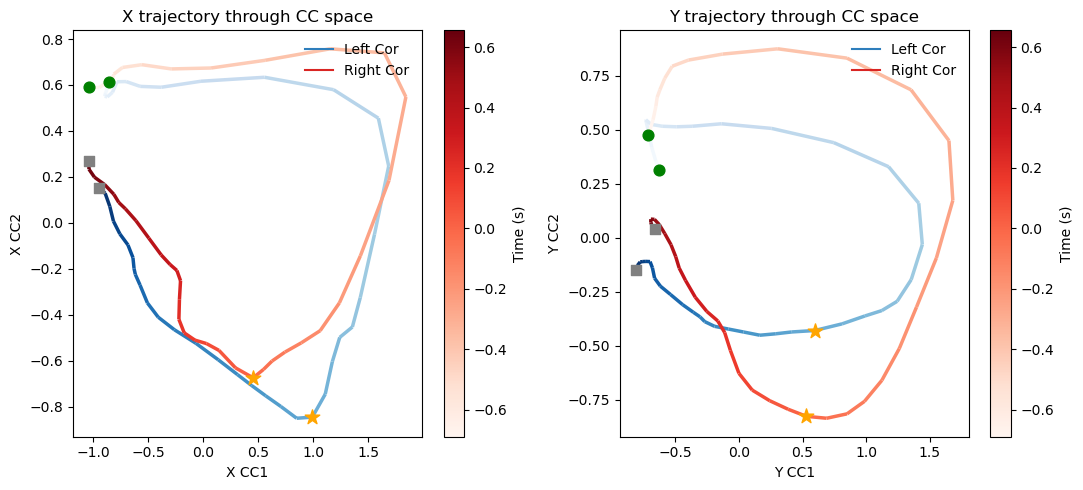

In [212]:
fig, (ax_x, ax_y), cca_trajectories = plot_cca_state_space(
    cca_res_shared,
    time=time_axis[mask],
    cond_colours={"Left Cor": "Blues", "Right Cor": "Reds"},
    cond_linestyles={"Left Cor": "-", "Right Cor": "-"},
    smooth_sigma=1
)




In [213]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import HTML

# trajectories - replace Left Cor or Right Cor with your actual condition names if different
X_left = np.asarray(
    cca_trajectories["X"]["trajectories"]["Left Cor"],
    dtype=float,
)
X_right = np.asarray(
    cca_trajectories["X"]["trajectories"]["Right Cor"],
    dtype=float,
)

Y_left = np.asarray(
    cca_trajectories["Y"]["trajectories"]["Left Cor"],
    dtype=float,
)
Y_right = np.asarray(
    cca_trajectories["Y"]["trajectories"]["Right Cor"],
    dtype=float,
)

n_frames = len(time_axis[mask])

for name, trajectory in {
    "X left": X_left,
    "X right": X_right,
    "Y left": Y_left,
    "Y right": Y_right,
}.items():
    if len(trajectory) != n_frames:
        raise ValueError(
            f"{name} has {len(trajectory)} timepoints, "
            f"but time has {n_frames}."
        )

time = time_axis[mask]
touch_time = 0.0
touch_idx = int(np.argmin(np.abs(np.asarray(time) - touch_time)))

print(
    f"Touch index: {touch_idx}, "
    f"corresponding time: {time[touch_idx]:.3f} s"
)
# shared plot limits
all_trajectories = np.vstack([
    X_left,
    X_right,
    Y_left,
    Y_right,
])

padding_x = 0.08 * np.ptp(all_trajectories[:, 0])
padding_y = 0.08 * np.ptp(all_trajectories[:, 1])

xlim = (
    all_trajectories[:, 0].min() - padding_x,
    all_trajectories[:, 0].max() + padding_x,
)
ylim = (
    all_trajectories[:, 1].min() - padding_y,
    all_trajectories[:, 1].max() + padding_y,
)

norm = plt.Normalize(time.min(), time.max())
# plot 
fig_anim, axes_anim = plt.subplots(
    1,
    2,
    figsize=(12, 5.5),
    sharex=True,
    sharey=True,
)

anim_panels = [
    (
        axes_anim[0],
        "npix CCA trajectories",
        X_left,
        X_right,
    ),
    (
        axes_anim[1],
        "zF CCA trajectories",
        Y_left,
        Y_right,
    ),
]

artists = {}

for ax, title, left_trajectory, right_trajectory in anim_panels:

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Canonical component 1", fontsize=11)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(alpha=0.15)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    # trajectory lines blue and red
    lc_left = LineCollection(
        [],
        cmap="Blues",
        norm=norm,
        linewidths=2.8,
        capstyle="round",
    )

    lc_right = LineCollection(
        [],
        cmap="Reds",
        norm=norm,
        linewidths=2.8,
        capstyle="round",
    )

    ax.add_collection(lc_left)
    ax.add_collection(lc_right)

    # Moving dots
    dot_left, = ax.plot(
        [],
        [],
        "o",
        color="tab:blue",
        markersize=9,
        zorder=5,
    )

    dot_right, = ax.plot(
        [],
        [],
        "o",
        color="tab:red",
        markersize=9,
        zorder=5,
    )

    # Trial-start markers
    ax.scatter(
        left_trajectory[0, 0],
        left_trajectory[0, 1],
        s=80,
        marker="o",
        facecolor="white",
        edgecolor="0.2",
        linewidth=1.4,
        zorder=5,
    )

    ax.scatter(
        right_trajectory[0, 0],
        right_trajectory[0, 1],
        s=80,
        marker="o",
        facecolor="white",
        edgecolor="0.2",
        linewidth=1.4,
        zorder=5,
    )

    # Empty touch markers; populated once touch is reached
    touch_left = ax.scatter(
        [],
        [],
        s=170,
        marker="*",
        facecolor="gold",
        edgecolor="0.2",
        linewidth=1.0,
        zorder=6,
    )

    touch_right = ax.scatter(
        [],
        [],
        s=170,
        marker="*",
        facecolor="gold",
        edgecolor="0.2",
        linewidth=1.0,
        zorder=6,
    )

    artists[ax] = {
        "lc_left": lc_left,
        "lc_right": lc_right,
        "dot_left": dot_left,
        "dot_right": dot_right,
        "touch_left": touch_left,
        "touch_right": touch_right,
        "left_traj": left_trajectory,
        "right_traj": right_trajectory,
    }


axes_anim[0].set_ylabel(
    "Canonical component 2",
    fontsize=11,
)

time_text = fig_anim.suptitle(
    "",
    fontsize=12,
    fontweight="bold",
    y=0.98,
)

legend_elements = [
    Line2D(
        [0],
        [0],
        color="tab:blue",
        lw=2.8,
        label="Move left",
    ),
    Line2D(
        [0],
        [0],
        color="tab:red",
        lw=2.8,
        label="Move right",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="0.2",
        markersize=9,
        label="Trial start",
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        color="none",
        markerfacecolor="gold",
        markeredgecolor="0.2",
        markersize=13,
        label="Touch",
    ),
]

fig_anim.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.06),
    frameon=False,
    fontsize=10,
)

fig_anim.subplots_adjust(
    top=0.82,
    wspace=0.18,
)

# animation funcs
def make_segments(trajectory, upto):
    """Create line segments from trajectory[0] up to trajectory[upto - 1]."""

    points = trajectory[:upto, :2].reshape(-1, 1, 2)

    if len(points) < 2:
        return np.empty((0, 2, 2))

    return np.concatenate(
        [points[:-1], points[1:]],
        axis=1,
    )


def update(frame):
    updated = []
    upto = frame + 1

    for art in artists.values():

        art["lc_left"].set_segments(
            make_segments(art["left_traj"], upto)
        )
        art["lc_right"].set_segments(
            make_segments(art["right_traj"], upto)
        )

        # There is one fewer line segment than trajectory points.
        segment_times = time[:max(upto - 1, 0)]

        art["lc_left"].set_array(segment_times)
        art["lc_right"].set_array(segment_times)

        art["dot_left"].set_data(
            [art["left_traj"][frame, 0]],
            [art["left_traj"][frame, 1]],
        )
        art["dot_right"].set_data(
            [art["right_traj"][frame, 0]],
            [art["right_traj"][frame, 1]],
        )

        if frame >= touch_idx:
            art["touch_left"].set_offsets(
                art["left_traj"][touch_idx, :2].reshape(1, 2)
            )
            art["touch_right"].set_offsets(
                art["right_traj"][touch_idx, :2].reshape(1, 2)
            )
        else:
            art["touch_left"].set_offsets(np.empty((0, 2)))
            art["touch_right"].set_offsets(np.empty((0, 2)))

        updated.extend([
            art["lc_left"],
            art["lc_right"],
            art["dot_left"],
            art["dot_right"],
            art["touch_left"],
            art["touch_right"],
        ])

    time_text.set_text(f"t = {time[frame]:+.2f} s")
    updated.append(time_text)

    return updated
anim = FuncAnimation(
    fig_anim,
    update,
    frames=n_frames,
    interval=40,
    blit=False,
    repeat=True,
)

plt.close(fig_anim)

video = HTML(anim.to_html5_video())
video

Touch index: 21, corresponding time: 0.017 s


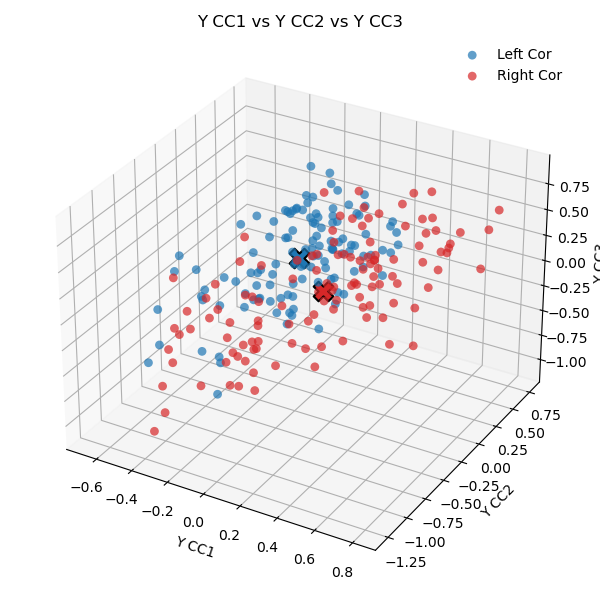

In [214]:
from CCA_analysis import plot_cca_scatter
%matplotlib widget

fig, ax, data = plot_cca_scatter(
    cca_res_shared,
    which="Y",
    conditions=[cond_1,cond_2],
    components=(0,1,2),
    show_centroids=True,
    cond_colours={"Left Cor": "tab:blue", "Right Cor": "tab:red"},
)

# decodidng

Decoding ['Left Cor'] (n=120) vs ['Right Cor'] (n=120) from Y CC[1, 2, 3], 42 timepoints, reg_method='lda'.


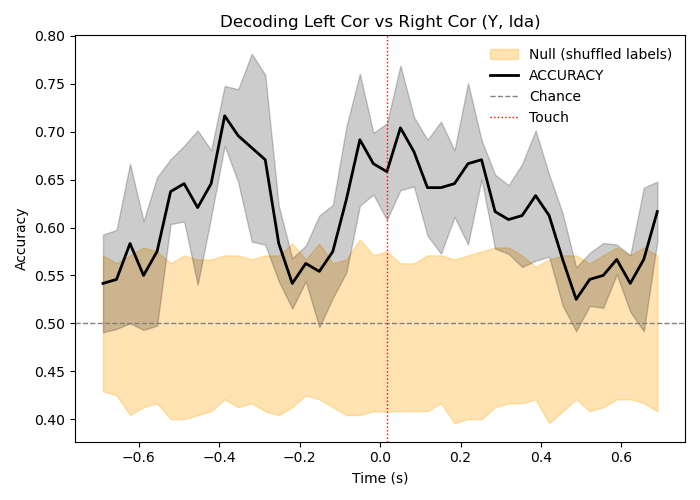

In [215]:
from CCA_analysis import plot_decode_accuracy, decode_cca_condition

decode_dir_res = decode_cca_condition(
    cca_res_shared,
    group_a=["Left Cor"],
    group_b=["Right Cor"],
    which="Y",              # or "Y" to decode from the cerebellar side
    reg_method="lda",
    components=(0,1,2),          
    scale=False,
    balance_conditions=True,
    n_permutations=200,
    random_state=42,
)
fig,ax = plot_decode_accuracy(decode_dir_res, time=organised.time_zF[mask])

# CCA cell loadings

In [216]:
import matplotlib.colors as mcolors

neuron_zone = organised.neuron_zone            # per-neuron microzone label, already validated
ordered_idx = np.argsort(neuron_zone)
sorted_zone = neuron_zone[ordered_idx]
boundaries = np.where(np.diff(sorted_zone) != 0)[0] + 0.5   # row positions where zone identity changes

zone_ids = np.unique(neuron_zone)
n_zones = len(zone_ids)
cmap_zone = plt.get_cmap('tab10', n_zones)
zone_rank = np.searchsorted(zone_ids, sorted_zone)
norm_zone = mcolors.BoundaryNorm(np.arange(n_zones + 1) - 0.5, n_zones)

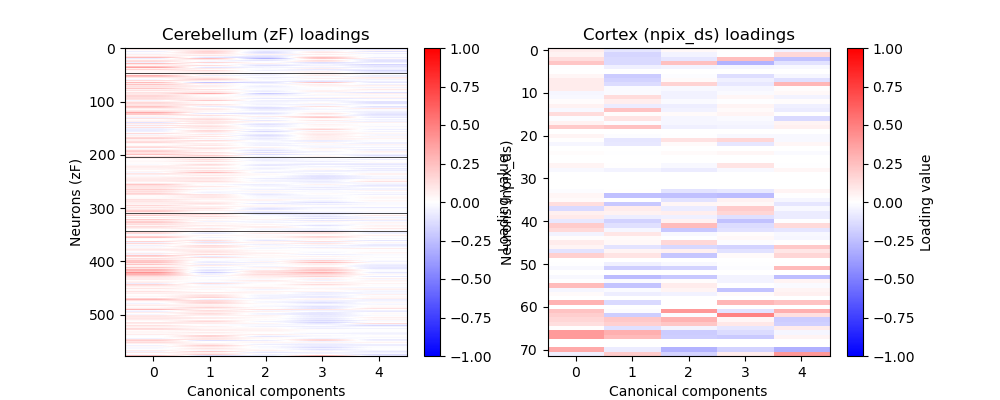

In [217]:
# plot CCA directional 
cca = cca_res_shared["cca"]
good_X = cca_res_shared["good_X"]   # bool mask, len 72 (npix)
good_Y = cca_res_shared["good_Y"]   # bool mask, len 578 (zF neurons)

n_components = cca.n_components

x_loadings_full = np.full((len(good_X), n_components), np.nan)
x_loadings_full[good_X] = cca.x_loadings_

y_loadings_full = np.full((len(good_Y), n_components), np.nan)
y_loadings_full[good_Y] = cca.y_loadings_

# sort neurons by microzone for y_loadings_full
y_loadings_full_sorted = y_loadings_full[ordered_idx]
# plot 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Cerebellum (zF) loadings")
plt.imshow(y_loadings_full_sorted, aspect="auto", cmap="bwr", vmin=-1, vmax=1)
# add lines to indicate microzone boundaries
for boundary in boundaries:
    plt.axhline(boundary, color="k", linewidth=0.5)
plt.colorbar(label="Loading value")
plt.xlabel("Canonical components")
plt.ylabel("Neurons (zF)")
plt.subplot(1, 2, 2)
plt.title("Cortex (npix_ds) loadings")
plt.imshow(x_loadings_full, aspect="auto", cmap="bwr", vmin=-1, vmax=1)
plt.colorbar(label="Loading value")
plt.xlabel("Canonical components")
plt.ylabel("Neurons (npix_ds)")
plt.show()

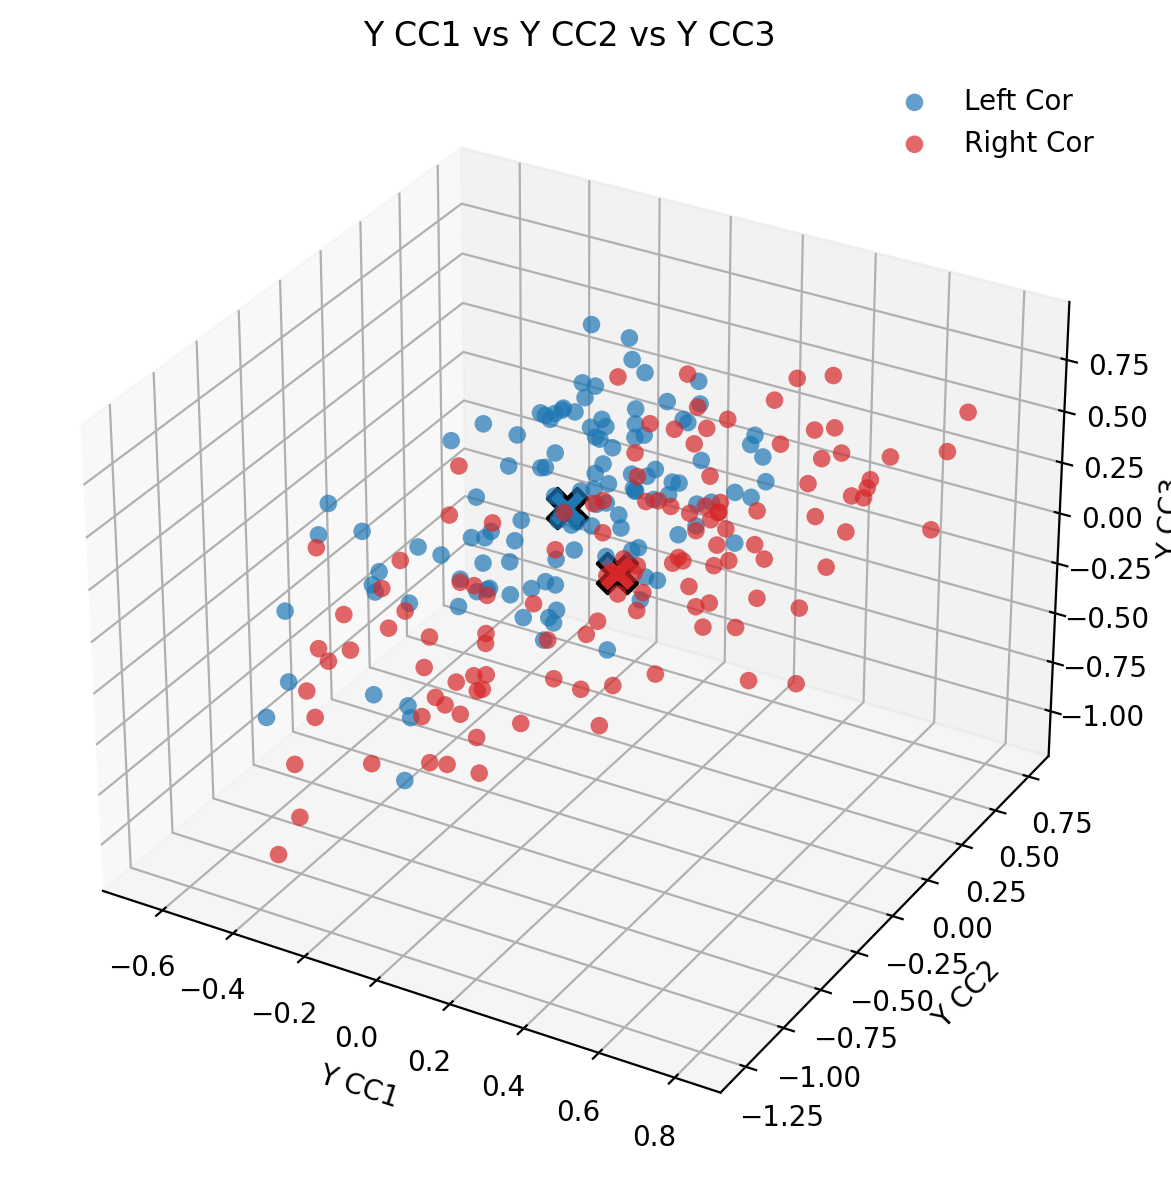

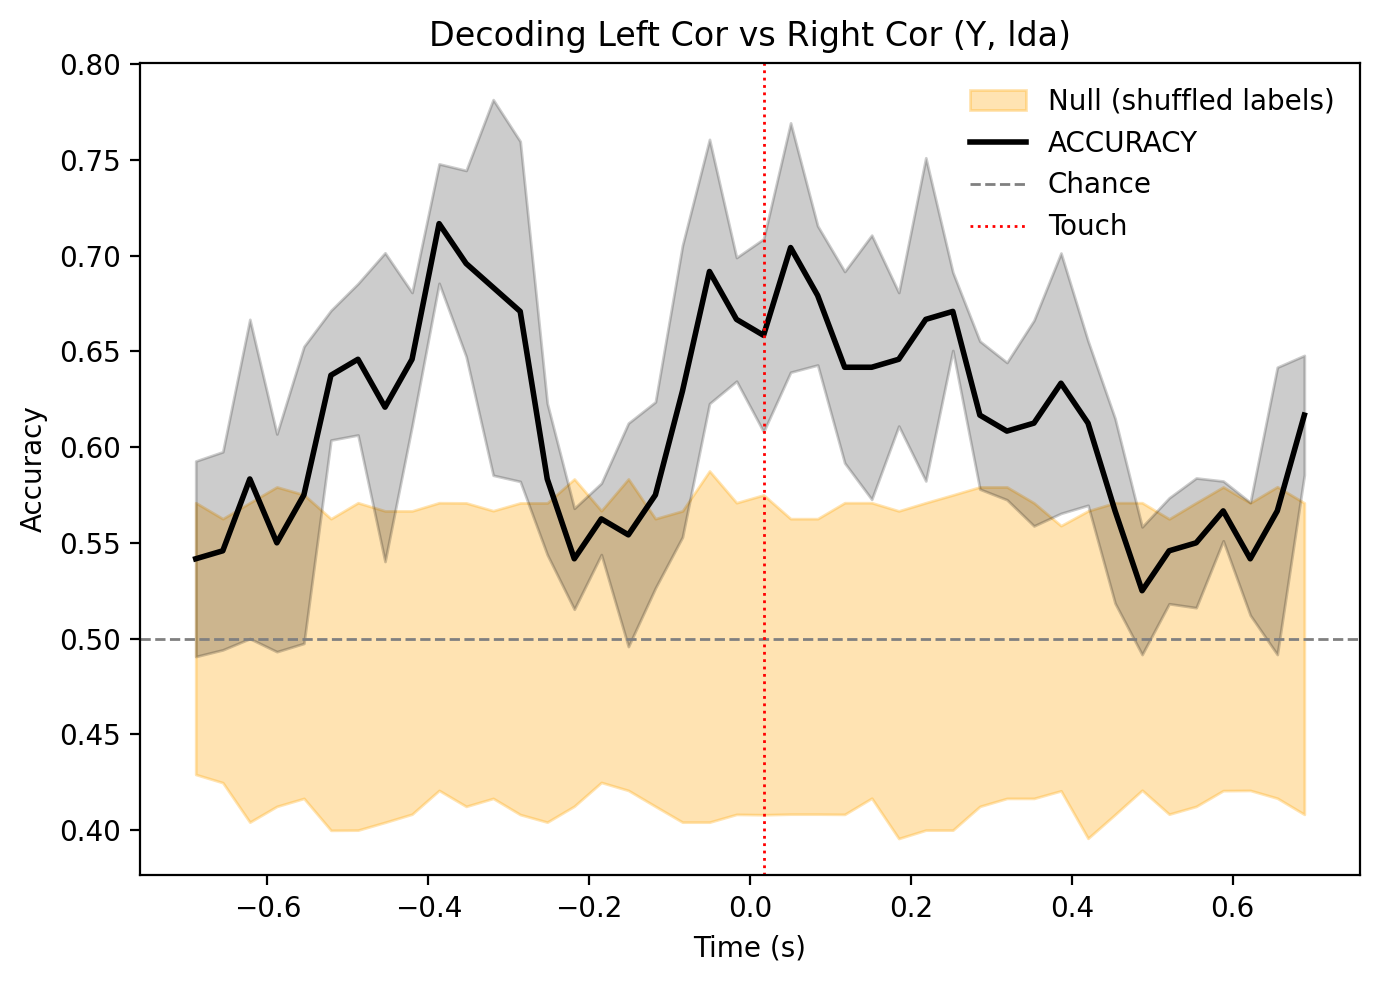

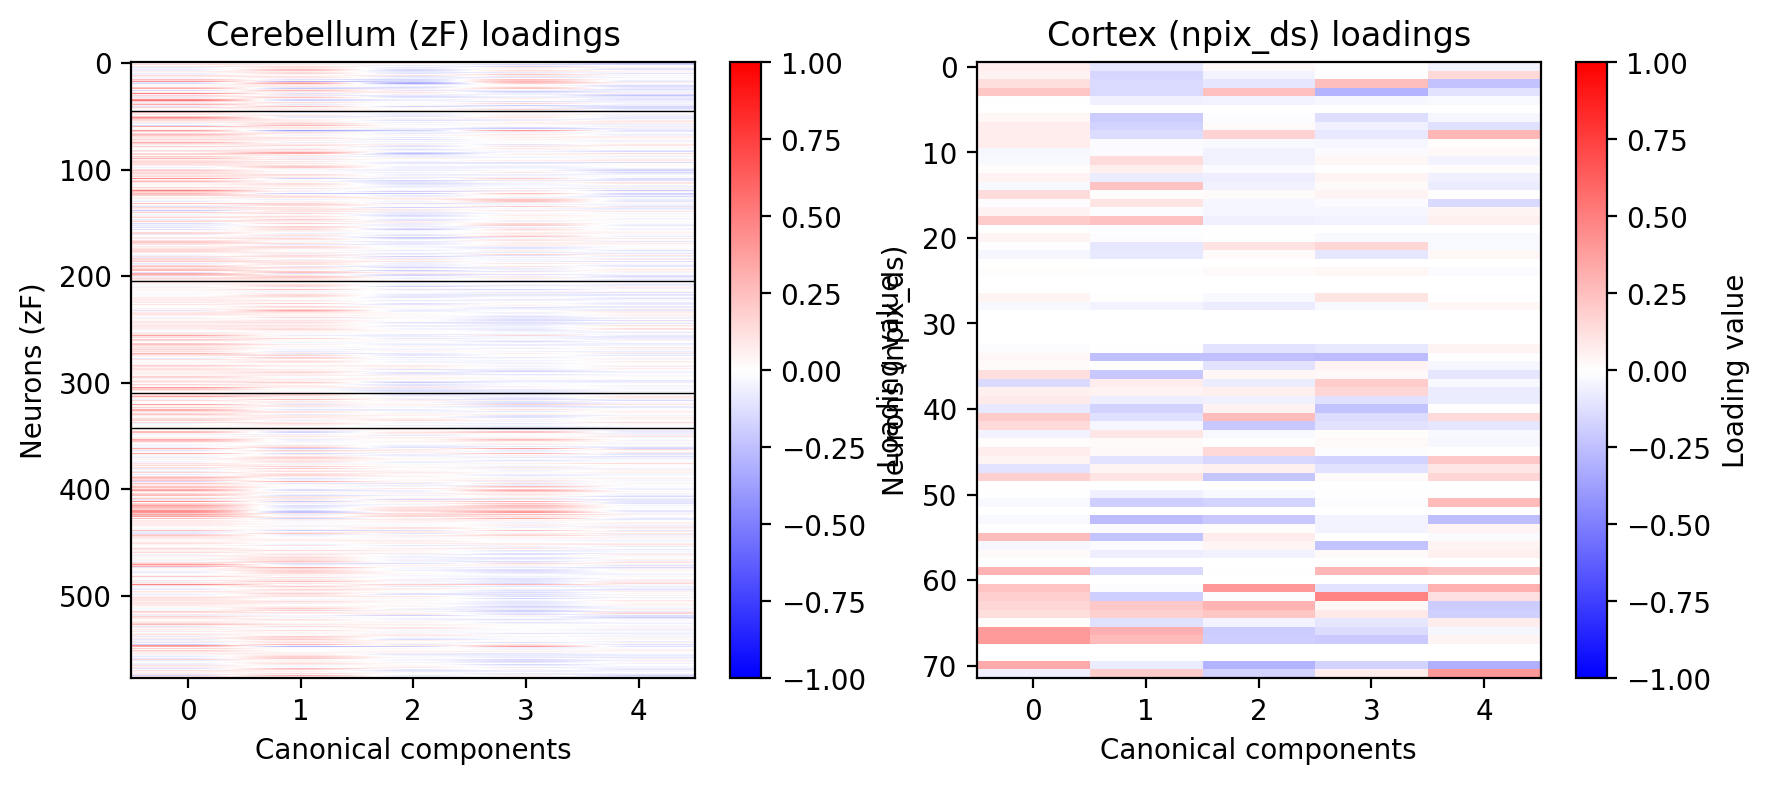

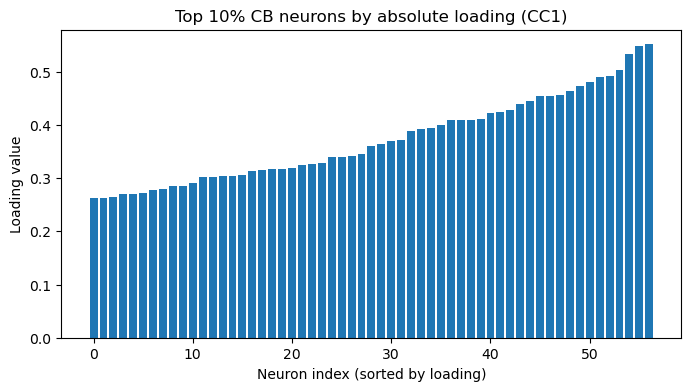

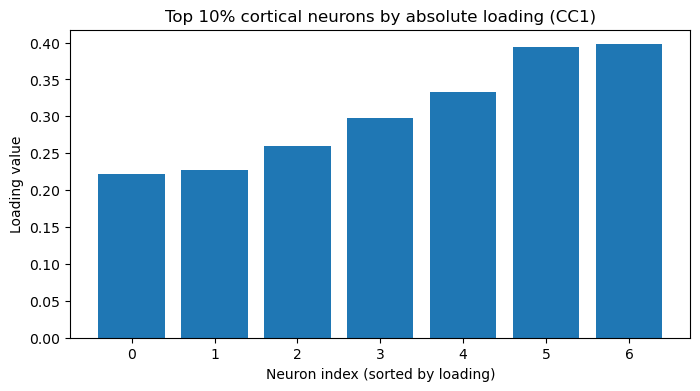

In [218]:
# get the top 10% of neurons based on their absolute loadings for the first canonical component
%matplotlib inline
top_percent = 0.1

# nan safe version
def top_k_by_abs_loading(loadings_col, k):
    vals = np.abs(loadings_col)
    vals_safe = np.where(np.isfinite(vals), vals, -np.inf)
    return np.argsort(vals_safe)[-k:]

n_top_neurons = int(len(y_loadings_full) * top_percent)
top_neuron_indices = top_k_by_abs_loading(y_loadings_full[:, 0], n_top_neurons)
# plot their loadings for the first canonical component
plt.figure(figsize=(8, 4))
plt.bar(range(n_top_neurons), y_loadings_full[top_neuron_indices, 0])
plt.title(f"Top {int(top_percent*100)}% CB neurons by absolute loading (CC1)")
plt.xlabel("Neuron index (sorted by loading)")

plt.ylabel("Loading value")
plt.show()

# take top 10% of cortical neurons based on their absolute loadings for the first canonical component
n_top_neurons = int(len(x_loadings_full) * top_percent)
top_cortical_indices = top_k_by_abs_loading(x_loadings_full[:, 0], n_top_neurons)
plt.figure(figsize=(8, 4))
plt.bar(range(len(top_cortical_indices)), x_loadings_full[top_cortical_indices, 0])
plt.title(f"Top {int(top_percent*100)}% cortical neurons by absolute loading (CC1)")
plt.xlabel("Neuron index (sorted by loading)")
plt.ylabel("Loading value")
plt.show()


In [174]:
# take only top indices and plot their activity averaged over trials but separated by left and right conditions
top_cortical_indices

array([61,  3, 59, 55, 66, 67, 70])

X_trials_top shape: (240, 42, 7), Y_trials_top shape: (240, 42, 57)
(120, 42, 7)
(120, 42, 7)
X_trial_left_avg shape: (42,), Y_trial_left_avg shape: (42,)
X_trial_right_avg shape: (42,), Y_trial_right_avg shape: (42,)


/var/folders/6c/kv9rjx1d2pl_7sgjzszvh8sc0000gn/T/ipykernel_31122/3317829133.py:7: RuntimeWarning: Mean of empty slice
  X_trials = (X_trials - np.nanmean(X_trials, axis=1, keepdims=True)) / np.nanstd(X_trials, axis=1, keepdims=True)
/var/folders/6c/kv9rjx1d2pl_7sgjzszvh8sc0000gn/T/ipykernel_31122/3317829133.py:7: RuntimeWarning: invalid value encountered in divide
  X_trials = (X_trials - np.nanmean(X_trials, axis=1, keepdims=True)) / np.nanstd(X_trials, axis=1, keepdims=True)


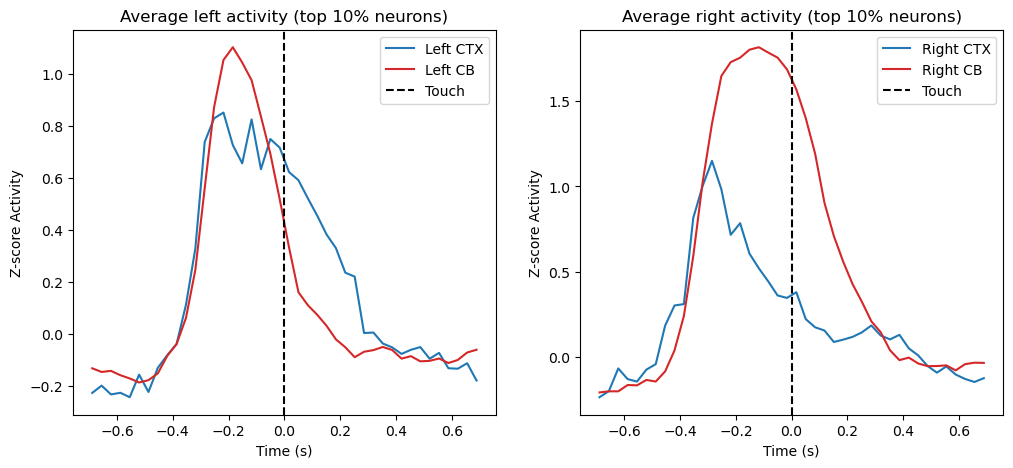

In [220]:
from CCA_analysis import collect_trials
X_trials, Y_trials, labels, neuron_idx = collect_trials(
    conditions,x_attr='npix_ds', y_attr='zF', verbose=False,
)

# z score X trial activity for each trial per neuron (npix_ds) to make it comparable to Y trial activity (zF)
X_trials = (X_trials - np.nanmean(X_trials, axis=1, keepdims=True)) / np.nanstd(X_trials, axis=1, keepdims=True)
X_trials = X_trials[:,mask,:]  # cut to time window
Y_trials = Y_trials[:,mask,:]  # cut to time window
X_trials_top = X_trials[:, :, top_cortical_indices]
Y_trials_top = Y_trials[:, :, top_neuron_indices]
print(f"X_trials_top shape: {X_trials_top.shape}, Y_trials_top shape: {Y_trials_top.shape}")

print(np.shape(X_trials_top[labels == "Left Cor"]))
print(np.shape(X_trials_top[labels == "Right Cor"]))
X_trial_left_avg = np.nanmean(X_trials_top[labels == "Left Cor"], axis=(0, 2))
Y_trial_left_avg = np.nanmean(Y_trials_top[labels == "Left Cor"], axis=(0, 2))
X_trial_right_avg = np.nanmean(X_trials_top[labels == "Right Cor"], axis=(0, 2))
Y_trial_right_avg = np.nanmean(Y_trials_top[labels == "Right Cor"], axis=(0, 2))
print(f"X_trial_left_avg shape: {X_trial_left_avg.shape}, Y_trial_left_avg shape: {Y_trial_left_avg.shape}")
print(f"X_trial_right_avg shape: {X_trial_right_avg.shape}, Y_trial_right_avg shape: {Y_trial_right_avg.shape}")

time_axis = organised.time_zF[mask]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_axis, X_trial_left_avg, color="tab:blue", label="Left CTX")
plt.plot(time_axis, Y_trial_left_avg, color="tab:red", label="Left CB")
plt.title("Average left activity (top 10% neurons)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score Activity")
plt.axvline(0, color="k", linestyle="--", label="Touch")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(time_axis, X_trial_right_avg, color="tab:blue", label="Right CTX")
plt.plot(time_axis, Y_trial_right_avg, color="tab:red", label="Right CB")
plt.title("Average right activity (top 10% neurons)")
plt.xlabel("Time (s)")
plt.ylabel("Z-score Activity")
plt.axvline(0, color="k", linestyle="--", label="Touch")
plt.legend()